📂 Loading files and sequence preparation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🔥 LSTM Training Started (Sequence Learning)...
Epoch 1/10
29365/29365 ━━━━━━━━━━━━━━━━━━━━ 336s 11ms/step - accuracy: 0.7699 - loss: 0.5655 - val_accuracy: 0.8573 - val_loss: 0.3405
Epoch 2/10
29365/29365 ━━━━━━━━━━━━━━━━━━━━ 326s 11ms/step - accuracy: 0.8594 - loss: 0.3398 - val_accuracy: 0.8768 - val_loss: 0.2870
Epoch 3/10
29365/29365 ━━━━━━━━━━━━━━━━━━━━ 329s 11ms/step - accuracy: 0.8768 - loss: 0.2949 - val_accuracy: 0.8870 - val_loss: 0.2660
Epoch 4/10
29365/29365 ━━━━━━━━━━━━━━━━━━━━ 382s 11ms/step - accuracy: 0.8856 - loss: 0.2715 - val_accuracy: 0.8945 - val_loss: 0.2431
Epoch 5/10
29365/29365 ━━━━━━━━━━━━━━━━━━━━ 320s 11ms/step - accuracy: 0.8909 - loss: 0.2572 - val_accuracy: 0.8931 - val_loss: 0.2550
Epoch 6/10
29365/29365 ━━━━━━━━━━━━━━━━━━━━ 320s 11ms/step - accuracy: 0.8951 - loss: 0.2467 - val_accuracy: 0.9022 - val_loss: 0.2252
Epoch 7/10
29365/29365 ━━━━━━━━━━━━━━━━━━━━ 320s 11ms/step - accuracy: 0.8982 - loss: 0.2387 - val_accuracy: 0.9034 - val_loss: 0.2222
Epoch 8

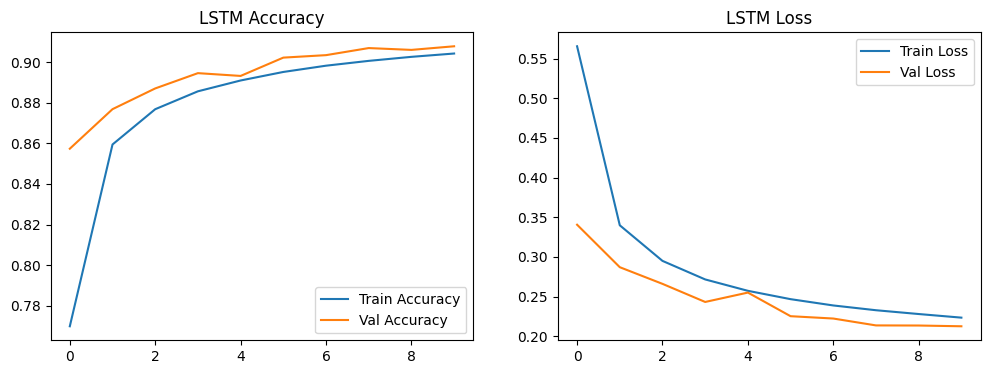

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import csv

# ==========================================
# 1. LOAD & CLEAN (Handling Extra Commas)
# ==========================================
files = ["merged_1star.csv", "merged_2star.csv", "merged_3star.csv", "merged_4star.csv", "merged_5star.csv"]
dfs = []

print("📂 Loading files and sequence preparation...")
for file in files:
    try:
        # Extra commas ignore karne ke liye on_bad_lines use kiya hai
        raw_df = pd.read_csv(file, sep=",", quoting=csv.QUOTE_NONE, on_bad_lines='skip')
        raw_df.columns = raw_df.columns.str.replace('"', '').str.strip()

        # Sirf core columns select karna
        cols = ['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro', 'Rating']
        temp_df = raw_df[cols].apply(pd.to_numeric, errors='coerce')

        if temp_df['Rating'].isnull().all():
            temp_df['Rating'] = int(file.split('_')[1][0])

        dfs.append(temp_df)
    except Exception as e:
        print(f"⚠️ Error in {file}: {e}")

df = pd.concat(dfs, ignore_index=True).dropna()

# ==========================================
# 2. SEQUENCE PREPARATION (The LSTM Secret)
# ==========================================
# LSTM ko 3D data chahiye (Samples, Time_Steps, Features)
def create_sequences(X, y, time_steps=20):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Features select karein
X_raw = df[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values
y_raw = df['Rating'].astype(int).values - 1 # 0-4 range

# Normalization (Neural networks ke liye zaroori hai)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Create sequences of 20 time-steps (approx 1-2 seconds of data)
TIME_STEPS = 20
X_seq, y_seq = create_sequences(X_scaled, y_raw, TIME_STEPS)

# One-hot encoding for GPT style training
y_seq = tf.keras.utils.to_categorical(y_seq, num_classes=5)

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

# ==========================================
# 3. LSTM MODEL ARCHITECTURE (High Power)
# ==========================================
model = Sequential([
    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    BatchNormalization(),

    LSTM(64),
    Dropout(0.3),
    BatchNormalization(),

    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 4. TRAINING (GPT STYLE)
# ==========================================
print("\n🔥 LSTM Training Started (Sequence Learning)...")
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 5. FINAL VISUALIZATION
# ==========================================
print(f"\n🎯 Final LSTM Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.legend()
plt.show()

14683/14683 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step


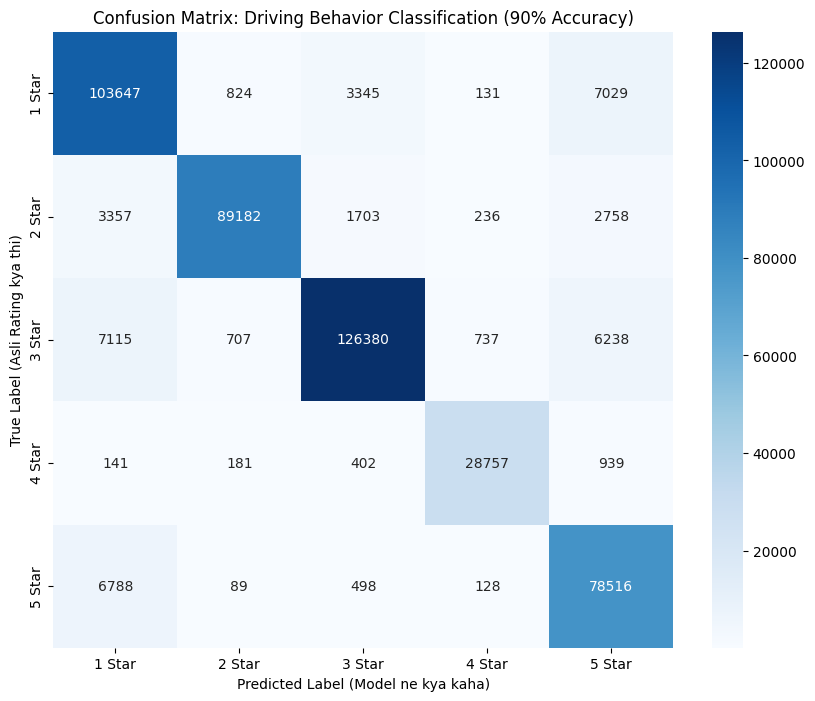


📝 Detailed Performance Report:

              precision    recall  f1-score   support

      1 Star       0.86      0.90      0.88    114976
      2 Star       0.98      0.92      0.95     97236
      3 Star       0.96      0.90      0.92    141177
      4 Star       0.96      0.95      0.95     30420
      5 Star       0.82      0.91      0.87     86019

    accuracy                           0.91    469828
   macro avg       0.91      0.91      0.91    469828
weighted avg       0.91      0.91      0.91    469828



In [2]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Predictions nikalna (Probabilities ko classes mein convert karna)
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Confusion Matrix generate karna
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 3. Plotting using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1 Star', '2 Star', '3 Star', '4 Star', '5 Star'],
            yticklabels=['1 Star', '2 Star', '3 Star', '4 Star', '5 Star'])

plt.xlabel('Predicted Label (Model ne kya kaha)')
plt.ylabel('True Label (Asli Rating kya thi)')
plt.title('Confusion Matrix: Driving Behavior Classification (90% Accuracy)')
plt.show()

# 4. Optional: Per-class accuracy dekhne ke liye
from sklearn.metrics import classification_report
print("\n📝 Detailed Performance Report:\n")
print(classification_report(y_true_classes, y_pred_classes,
                            target_names=['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']))

/tmp/ipykernel_945/1010160266.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=driver_labels, y=type_counts.values, palette='viridis')


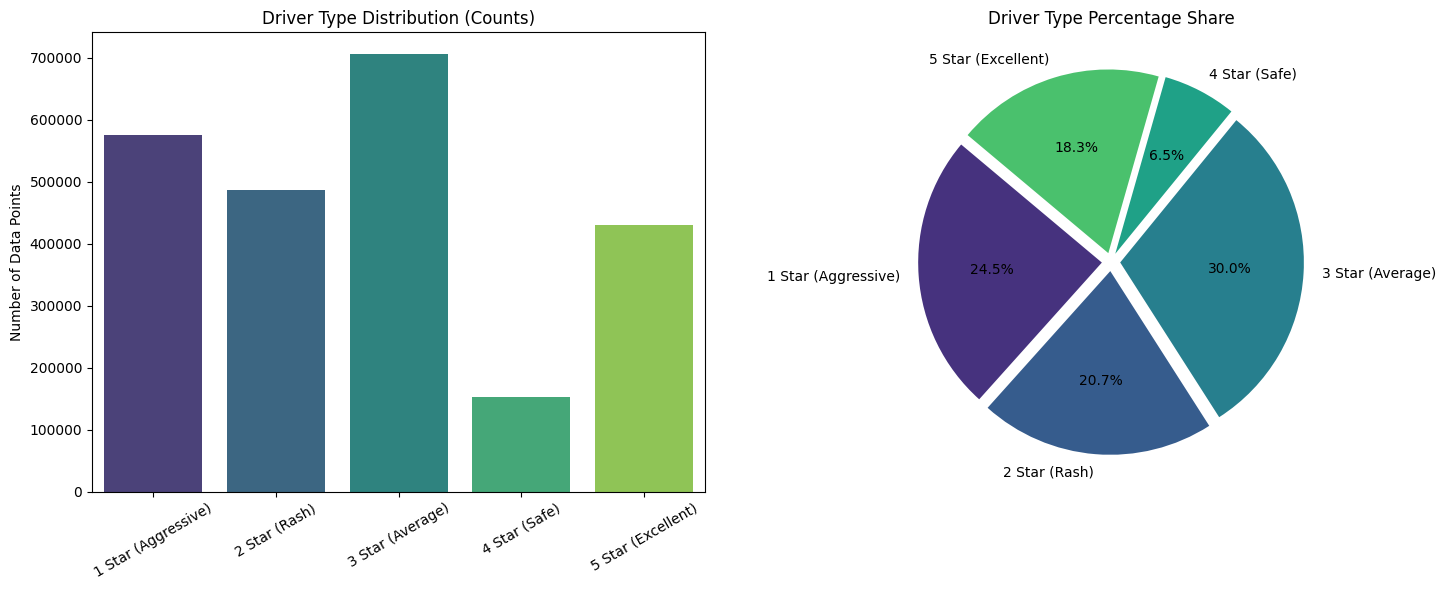


📊 DRIVER TYPE SUMMARY:
1 Star (Aggressive): 574900 samples (24.47%)
2 Star (Rash): 486181 samples (20.70%)
3 Star (Average): 705882 samples (30.05%)
4 Star (Safe): 152098 samples (6.47%)
5 Star (Excellent): 430097 samples (18.31%)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Driver Types ke labels define karein
driver_labels = ['1 Star (Aggressive)', '2 Star (Rash)', '3 Star (Average)', '4 Star (Safe)', '5 Star (Excellent)']

# 2. Dataset se counts nikalna
# Note: Agar aapne y ko 0-4 range mein convert kiya tha toh counts usi order mein aayenge
type_counts = df['Rating'].value_counts().sort_index()

# 3. Bar Chart aur Pie Chart ek saath
plt.figure(figsize=(15, 6))

# Subplot 1: Bar Chart (Count dikhane ke liye)
plt.subplot(1, 2, 1)
sns.barplot(x=driver_labels, y=type_counts.values, palette='viridis')
plt.title('Driver Type Distribution (Counts)')
plt.xticks(rotation=30)
plt.ylabel('Number of Data Points')

# Subplot 2: Pie Chart (Percentage dikhane ke liye)
plt.subplot(1, 2, 2)
plt.pie(type_counts.values, labels=driver_labels, autopct='%1.1f%%',
        colors=sns.color_palette('viridis'), startangle=140, explode=[0.05]*5)
plt.title('Driver Type Percentage Share')

plt.tight_layout()
plt.show()

# 4. Summary Print karein
print("\n📊 DRIVER TYPE SUMMARY:")
for label, count in zip(driver_labels, type_counts.values):
    percentage = (count / len(df)) * 100
    print(f"{label}: {count} samples ({percentage:.2f}%)")

In [6]:
import numpy as np

# 1. Ek random sample uthate hain Test Data se
sample_idx = np.random.randint(0, len(X_test))
sample_window = X_test[sample_idx : sample_idx + 1]

# 2. Model se prediction mangte hain
prediction_probs = model.predict(sample_window, verbose=0)
predicted_class = np.argmax(prediction_probs) + 1 # 0-4 ko 1-5 mein convert kiya

# 3. Driving Score (0-100) Logic
# 1 Star = 20, 2 Star = 40, 3 Star = 60, 4 Star = 80, 5 Star = 100
weights = np.array([20, 40, 60, 80, 100])
driving_score = np.dot(prediction_probs[0], weights)

# 4. Result Print Karein
print("="*40)
print("🚦 DRIVER EVALUATION REPORT 🚦")
print("="*40)
print(f"🔹 Analysis Window : 20 Time-steps (~2 sec)")
print(f"🔹 Predicted Rating: {predicted_class} Star")
print(f"🔹 FINAL DRIVING SCORE: {driving_score:.2f} / 100")
print("="*40)

# 5. Interpretation
if driving_score >= 80:
    print("✅ Status: Excellent Driver (Safe & Smooth)")
elif driving_score >= 60:
    print("🟡 Status: Good Driver (Minor Aggression)")
elif driving_score >= 40:
    print("🟠 Status: Average Driver (Needs Improvement)")
else:
    print("🔴 Status: Risky Driver (High Rashness/Jerk)")

🚦 DRIVER EVALUATION REPORT 🚦
🔹 Analysis Window : 20 Time-steps (~2 sec)
🔹 Predicted Rating: 3 Star
🔹 FINAL DRIVING SCORE: 65.30 / 100
🟡 Status: Good Driver (Minor Aggression)
